In [1]:
%%writefile /home/afzal/projects/knee-oa-classification/src/data.py
"""Data loading: processed .npz arrays -> tf.data pipelines."""
from pathlib import Path
import numpy as np
import tensorflow as tf

PROJECT = Path.home() / "projects/knee-oa-classification"
PROCESSED = PROJECT / "data/processed"
NUM_CLASSES = 5


def load_split(split):
    """Return (X, y) for 'train', 'val' or 'test'. X is uint8 (N, 224, 224)."""
    with np.load(PROCESSED / f"{split}.npz") as d:
        return d["X"], d["y"]


def make_dataset(X, y, batch_size=32, shuffle=False, augment=None, seed=42):
    """Build a tf.data pipeline: scale to [0, 1], add channel dim, batch, prefetch.

    augment: optional Keras layer/model applied to each training batch.
    """
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, t: (tf.cast(x[..., None], tf.float32) / 255.0, t),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    if augment is not None:
        ds = ds.map(lambda x, t: (augment(x, training=True), t),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

Writing /home/afzal/projects/knee-oa-classification/src/data.py


In [2]:
%%writefile /home/afzal/projects/knee-oa-classification/src/evaluation.py
"""Evaluation harness: metrics, confusion matrix, balanced-accuracy callback, results log."""
import csv
import json
from datetime import datetime
from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix, f1_score, recall_score)

GRADES = [0, 1, 2, 3, 4]
RESULTS_CSV = Path.home() / "projects/knee-oa-classification/reports/results.csv"


def set_seed(seed=42):
    """Seed Python, NumPy and TensorFlow for reproducible runs."""
    keras.utils.set_random_seed(seed)


def compute_metrics(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, labels=GRADES, average=None, zero_division=0)
    m = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "macro_f1": f1_score(y_true, y_pred, labels=GRADES, average="macro", zero_division=0),
    }
    m.update({f"recall_g{g}": r for g, r in zip(GRADES, recalls)})
    return {k: float(v) for k, v in m.items()}


def plot_confusion_matrix(y_true, y_pred, title="", save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=GRADES)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(len(GRADES)):
        for j in range(len(GRADES)):
            ax.text(j, i, f"{cm[i, j]}\n{cm_norm[i, j]:.0%}", ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)
    ax.set_xticks(GRADES)
    ax.set_yticks(GRADES)
    ax.set_xlabel("Predicted grade")
    ax.set_ylabel("True grade")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def evaluate_predictions(y_true, y_pred, title="", save_path=None):
    """Print headline metrics and per-class report, plot the confusion matrix."""
    m = compute_metrics(y_true, y_pred)
    print(f"Balanced accuracy: {m['balanced_accuracy']:.4f} | Accuracy: {m['accuracy']:.4f} | "
          f"QWK: {m['qwk']:.4f} | Macro F1: {m['macro_f1']:.4f}\n")
    print(classification_report(y_true, y_pred, labels=GRADES, digits=3, zero_division=0))
    plot_confusion_matrix(y_true, y_pred, title, save_path)
    plt.show()
    return m


class BalancedAccuracyCallback(keras.callbacks.Callback):
    """Adds 'val_balanced_accuracy' and 'val_qwk' to the epoch logs.

    Must be listed BEFORE ModelCheckpoint / EarlyStopping in the callbacks list,
    so they can monitor 'val_balanced_accuracy'. val_ds must NOT be shuffled.
    """

    def __init__(self, val_ds, y_val):
        super().__init__()
        self.val_ds = val_ds
        self.y_val = np.asarray(y_val)

    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(self.val_ds, verbose=0).argmax(axis=1)
        logs = logs if logs is not None else {}
        logs["val_balanced_accuracy"] = float(balanced_accuracy_score(self.y_val, y_pred))
        logs["val_qwk"] = float(cohen_kappa_score(self.y_val, y_pred, weights="quadratic"))
        print(f"  val_balanced_accuracy: {logs['val_balanced_accuracy']:.4f}"
              f" | val_qwk: {logs['val_qwk']:.4f}")


def log_run(run_name, config, metrics, split="val", path=RESULTS_CSV):
    """Append one experiment's config and metrics to reports/results.csv."""
    row = {"timestamp": datetime.now().isoformat(timespec="seconds"),
           "run": run_name, "split": split,
           **{k: round(v, 4) for k, v in metrics.items()},
           "config": json.dumps(config)}
    path.parent.mkdir(parents=True, exist_ok=True)
    is_new = not path.exists()
    with open(path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(row))
        if is_new:
            writer.writeheader()
        writer.writerow(row)
    return row

Writing /home/afzal/projects/knee-oa-classification/src/evaluation.py


In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np

PROJECT = Path.home() / "projects/knee-oa-classification"
sys.path.insert(0, str(PROJECT / "src"))

import data
import evaluation as ev

X_train, y_train = data.load_split("train")
X_val, y_val = data.load_split("val")
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val)]:
    print(f"{name:5s} X {X.shape} {X.dtype} range [{X.min()}, {X.max()}] | per grade {np.bincount(y)}")

train_ds = data.make_dataset(X_train, y_train, batch_size=32, shuffle=True)
val_ds = data.make_dataset(X_val, y_val, batch_size=64)

xb, yb = next(iter(train_ds))
print(f"\nOne training batch: {tuple(xb.shape)} {xb.dtype}, "
      f"values [{float(xb.numpy().min()):.2f}, {float(xb.numpy().max()):.2f}], "
      f"first labels {yb.numpy()[:10]}")

I0000 00:00:1791026829.124755    2255 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791026829.414902    2255 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791026830.957895    2255 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


train X (5778, 224, 224) uint8 range [1, 255] | per grade [2286 1046 1516  757  173]
val   X (826, 224, 224) uint8 range [1, 255] | per grade [328 153 212 106  27]


I0000 00:00:1791026834.140216    2255 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



One training batch: (32, 224, 224, 1) <dtype: 'float32'>, values [0.00, 1.00], first labels [0 4 0 0 3 0 3 2 3 1]


always_grade_0  balanced_acc 0.200 | acc 0.397 | qwk 0.000 | macro_f1 0.114
random_uniform  balanced_acc 0.201 | acc 0.201 | qwk 0.018 | macro_f1 0.180
perfect         balanced_acc 1.000 | acc 1.000 | qwk 1.000 | macro_f1 1.000

Balanced accuracy: 0.2000 | Accuracy: 0.3971 | QWK: 0.0000 | Macro F1: 0.1137

              precision    recall  f1-score   support

           0      0.397     1.000     0.568       328
           1      0.000     0.000     0.000       153
           2      0.000     0.000     0.000       212
           3      0.000     0.000     0.000       106
           4      0.000     0.000     0.000        27

    accuracy                          0.397       826
   macro avg      0.079     0.200     0.114       826
weighted avg      0.158     0.397     0.226       826



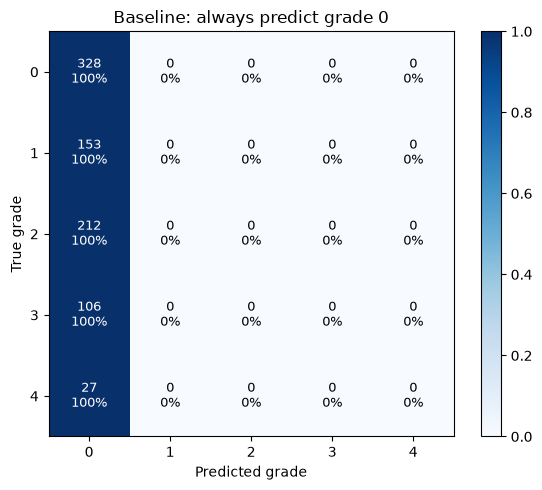

{'timestamp': '2026-10-03T11:27:42',
 'run': 'baseline_always_0',
 'split': 'val',
 'balanced_accuracy': 0.2,
 'accuracy': 0.3971,
 'qwk': 0.0,
 'macro_f1': 0.1137,
 'recall_g0': 1.0,
 'recall_g1': 0.0,
 'recall_g2': 0.0,
 'recall_g3': 0.0,
 'recall_g4': 0.0,
 'config': '{"type": "constant", "prediction": 0}'}

In [4]:
rng = np.random.default_rng(42)
baselines = {
    "always_grade_0": np.zeros_like(y_val),
    "random_uniform": rng.integers(0, 5, size=len(y_val)),
    "perfect": y_val.copy(),
}
for name, pred in baselines.items():
    m = ev.compute_metrics(y_val, pred)
    print(f"{name:15s} balanced_acc {m['balanced_accuracy']:.3f} | acc {m['accuracy']:.3f} | "
          f"qwk {m['qwk']:.3f} | macro_f1 {m['macro_f1']:.3f}")

print()
m0 = ev.evaluate_predictions(y_val, baselines["always_grade_0"],
                             title="Baseline: always predict grade 0",
                             save_path=PROJECT / "reports/cm_baseline_always_0.png")
ev.log_run("baseline_always_0", {"type": "constant", "prediction": 0}, m0)

In [7]:
import keras

ev.set_seed(42)
model = keras.Sequential([
    keras.Input(shape=(224, 224, 1)),
    keras.layers.Conv2D(8, 3, strides=2, activation="relu"),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(5, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

MODELS = PROJECT / "models"
MODELS.mkdir(exist_ok=True)
ckpt_path = MODELS / "smoke_test.keras"

callbacks = [
    ev.BalancedAccuracyCallback(val_ds, y_val),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_balanced_accuracy",
                                    mode="max", save_best_only=True, verbose=1),
]
history = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=callbacks)

print("\nKeys recorded in history:", list(history.history))
print("Checkpoint saved:", ckpt_path.exists())

Epoch 1/2


/home/afzal/miniconda3/envs/knee-oa/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791026980.649718    2489 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4071__.14


164/181 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3053 - loss: 1.5262

I0000 00:00:1791026982.025789    2487 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4071__.14


181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3155 - loss: 1.5169  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000

Epoch 1: val_balanced_accuracy improved from None to 0.20000, saving model to /home/afzal/projects/knee-oa-classification/models/smoke_test.keras

Epoch 1: finished saving model to /home/afzal/projects/knee-oa-classification/models/smoke_test.keras
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3155 - loss: 1.5169 - val_accuracy: 0.3971 - val_loss: 1.4248 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00
Epoch 2/2
175/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3939 - loss: 1.4075  val_balanced_accuracy: 0.2000 | val_qwk: 0.0000

Epoch 2: val_balanced_accuracy did not improve from 0.20000
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3956 - loss: 1.4055 - val_accuracy: 0.3971 - val_loss: 1.4037 - val_balanced_accuracy: 0.2000 - val_qwk: 0.0000e+00

Keys recorded in history: ['accuracy', 'loss', 'val_accuracy', 'val_loss', 'val_balance

In [9]:
import pandas as pd
pd.read_csv(PROJECT / "reports/results.csv")

,timestamp,run,split,balanced_accuracy,accuracy,qwk,macro_f1,recall_g0,recall_g1,recall_g2,recall_g3,recall_g4,config
0,2026-10-03T11:27:42,baseline_always_0,val,0.2,0.3971,0.0,0.1137,1.0,0.0,0.0,0.0,0.0,"{""type"": ""constant"", ""prediction"": 0}"
